# Disease Prediction from Medical Data

**Objective:** Predict disease status from structured patient/medical data using classification algorithms.

This notebook covers three datasets:
1. **Heart Disease**
2. **Diabetes**
3. **Breast Cancer**

Models:
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- XGBoost

Evaluation:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix
- ROC curve
- Model comparison

## 1.Import Libraries

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)
from xgboost import XGBClassifier
RANDOM_STATE = 42

## 2. Load and standardize the three datasets

In [2]:
heart_df = pd.read_csv("heart.csv")
diabetes_df = pd.read_csv("diabetes.csv")
breast_df = pd.read_csv("brest_cancer.csv")

print("Heart:", heart_df.shape)
display(heart_df.head())
print("Diabetes:", diabetes_df.shape)
display(diabetes_df.head())
print("Breast cancer:", breast_df.shape)
display(breast_df.head())

Heart: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Diabetes: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Breast cancer: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print("HEART COLUMNS")
print(heart_df.columns.tolist())

print("\nDIABETES COLUMNS")
print(diabetes_df.columns.tolist())

print("\nBREAST CANCER COLUMNS")
print(breast_df.columns.tolist())


HEART COLUMNS
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

DIABETES COLUMNS
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

BREAST CANCER COLUMNS
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


## 3. Basic data inspection


In [4]:
def inspect_df(df, name):
    print(f"===== {name} =====")
    print("Shape:", df.shape)
    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False).head(15))
    print("\nData types:")
    print(df.dtypes.value_counts())
    print("\nDuplicate rows:", df.duplicated().sum())
    display(df.describe(include="all").T.head(20))

inspect_df(heart_df, "Heart Disease")
inspect_df(diabetes_df, "Diabetes")
inspect_df(breast_df, "Breast Cancer")


===== Heart Disease =====
Shape: (297, 14)

Missing values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Data types:
int64      13
float64     1
Name: count, dtype: int64

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,2.158249,0.964859,0.0,2.0,2.0,3.0,3.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


===== Diabetes =====
Shape: (768, 9)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data types:
int64      7
float64    2
Name: count, dtype: int64

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


===== Breast Cancer =====
Shape: (569, 33)

Missing values:
Unnamed: 32                569
compactness_se               0
fractal_dimension_worst      0
symmetry_worst               0
concave points_worst         0
concavity_worst              0
compactness_worst            0
smoothness_worst             0
area_worst                   0
perimeter_worst              0
texture_worst                0
radius_worst                 0
fractal_dimension_se         0
symmetry_se                  0
concave points_se            0
dtype: int64

Data types:
float64    31
int64       1
object      1
Name: count, dtype: int64

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,569.0,NaN,NaN,NaN,30371831.432337,125020585.612224,8670.0,869218.0,906024.0,8813129.0,911320502.0
diagnosis,569,2,B,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
radius_mean,569.0,NaN,NaN,NaN,14.127292,3.524049,6.981,11.7,13.37,15.78,28.11
texture_mean,569.0,NaN,NaN,NaN,19.289649,4.301036,9.71,16.17,18.84,21.8,39.28
perimeter_mean,569.0,NaN,NaN,NaN,91.969033,24.298981,43.79,75.17,86.24,104.1,188.5
area_mean,569.0,NaN,NaN,NaN,654.889104,351.914129,143.5,420.3,551.1,782.7,2501.0
smoothness_mean,569.0,NaN,NaN,NaN,0.09636,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,NaN,NaN,NaN,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,NaN,NaN,NaN,0.088799,0.07972,0.0,0.02956,0.06154,0.1307,0.4268
concave points_mean,569.0,NaN,NaN,NaN,0.048919,0.038803,0.0,0.02031,0.0335,0.074,0.2012


## 4. Target-column preparation

Each dataset is converted into a binary classification problem:

- **Heart:** no disease = 0, disease = 1
- **Diabetes:** no diabetes = 0, diabetes = 1
- **Breast cancer:** benign = 0, malignant = 1


In [5]:
def detect_target(df, candidates):
    lower = {str(c).lower().strip(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    raise ValueError(f"Could not detect target. Available columns: {df.columns.tolist()}")

def prepare_heart(df):
    df = df.copy()
    target = detect_target(df, ["target", "condition", "num", "goal", "heartdisease", "heart_disease"])
    y = pd.to_numeric(df[target], errors="coerce")
    # Cleveland/UCI variants commonly use 0 = no disease and positive values = disease.
    y = (y > 0).astype(int)
    X = df.drop(columns=[target])
    return X, y, target

def prepare_diabetes(df):
    df = df.copy()
    target = detect_target(df, ["outcome", "diabetes", "target"])
    y = pd.to_numeric(df[target], errors="coerce").astype(int)
    X = df.drop(columns=[target])
    return X, y, target

def prepare_breast(df):
    df = df.copy()
    target = detect_target(df, ["diagnosis", "target", "label", "class"])
    y_raw = df[target].astype(str).str.strip().str.upper()
    # Wisconsin Diagnostic: M = malignant, B = benign.
    y = y_raw.map({"B": 0, "M": 1})
    if y.isna().any():
        # Fallback for numeric 0/1 targets.
        y = pd.to_numeric(df[target], errors="coerce")
        y = (y > 0).astype(int)
    X = df.drop(columns=[target])
    # Remove identifier columns if present.
    id_like = [c for c in X.columns if str(c).lower() in {"id", "unnamed: 32", "unnamed: 0"}]
    X = X.drop(columns=id_like, errors="ignore")
    return X, y, target

datasets = {}

for name, preparer, raw in [
    ("Heart Disease", prepare_heart, heart_df),
    ("Diabetes", prepare_diabetes, diabetes_df),
    ("Breast Cancer", prepare_breast, breast_df),
]:
    X, y, target = preparer(raw)
    valid = y.notna()
    X, y = X.loc[valid].copy(), y.loc[valid].copy()
    # Convert non-numeric columns to numeric where possible.
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    datasets[name] = (X, y)
    print(f"{name}: X={X.shape}, target='{target}', classes={y.value_counts().sort_index().to_dict()}")


Heart Disease: X=(297, 13), target='condition', classes={0: 160, 1: 137}
Diabetes: X=(768, 8), target='Outcome', classes={0: 500, 1: 268}
Breast Cancer: X=(569, 30), target='diagnosis', classes={0: 357, 1: 212}


## 5. Exploratory Data Analysis


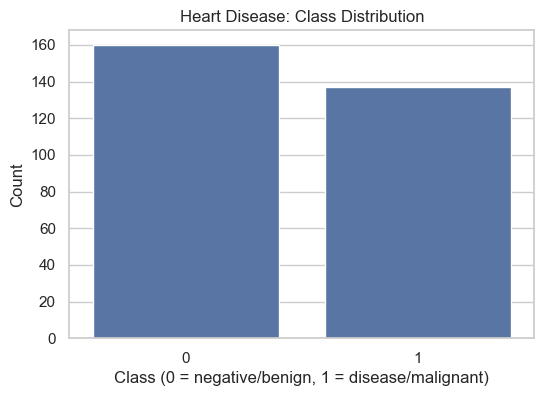

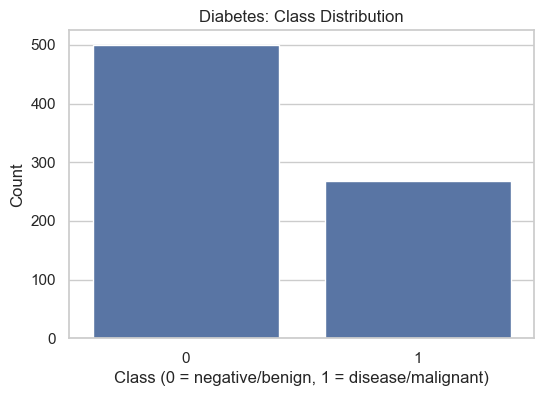

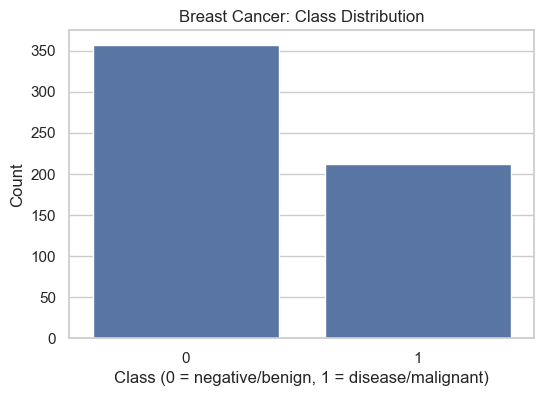

In [6]:
for name, (X, y) in datasets.items():
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y)
    plt.title(f"{name}: Class Distribution")
    plt.xlabel("Class (0 = negative/benign, 1 = disease/malignant)")
    plt.ylabel("Count")
    plt.show()


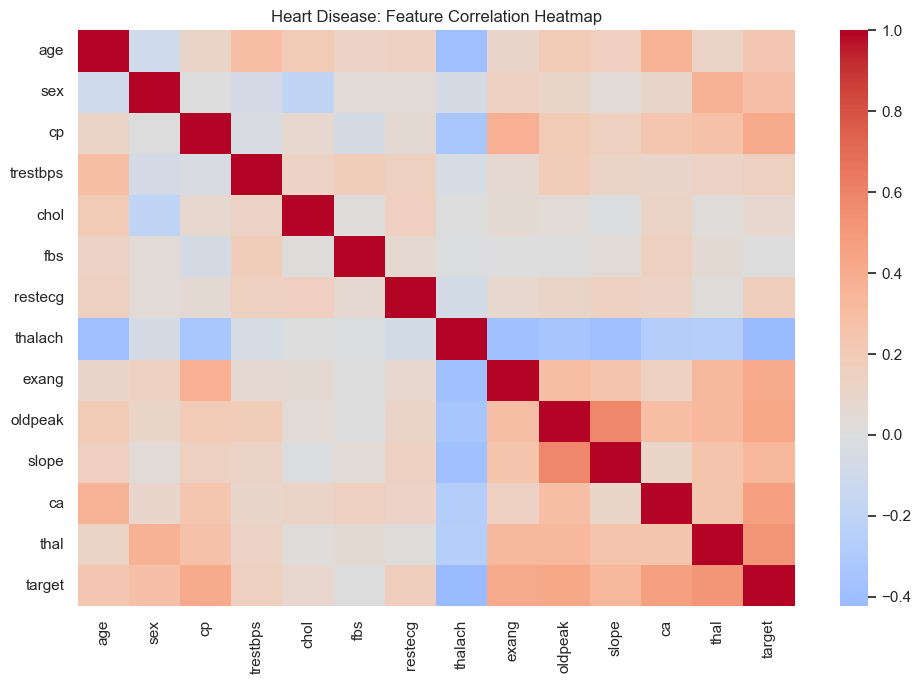

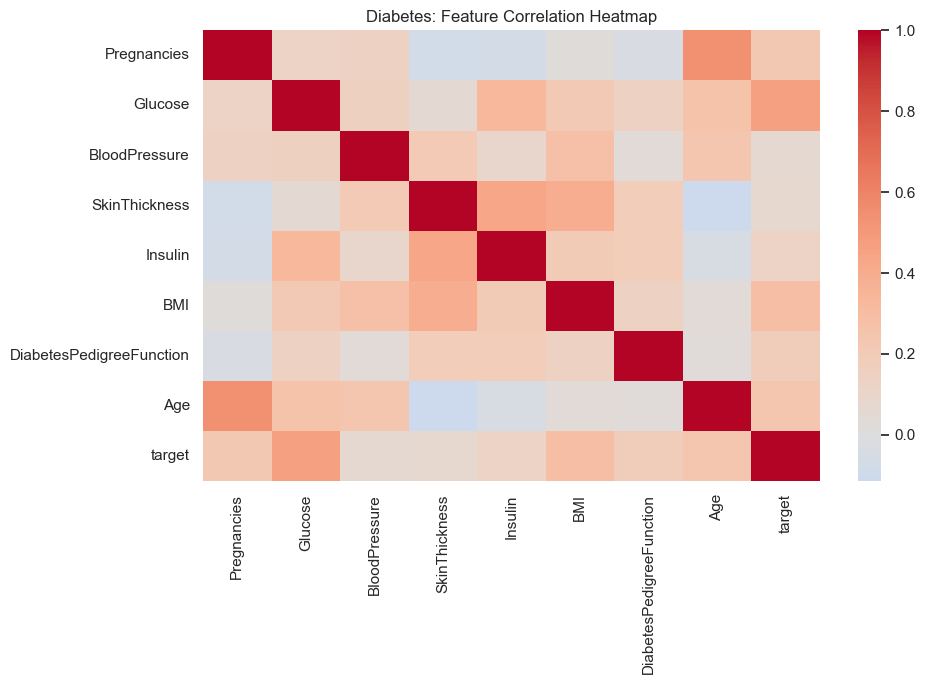

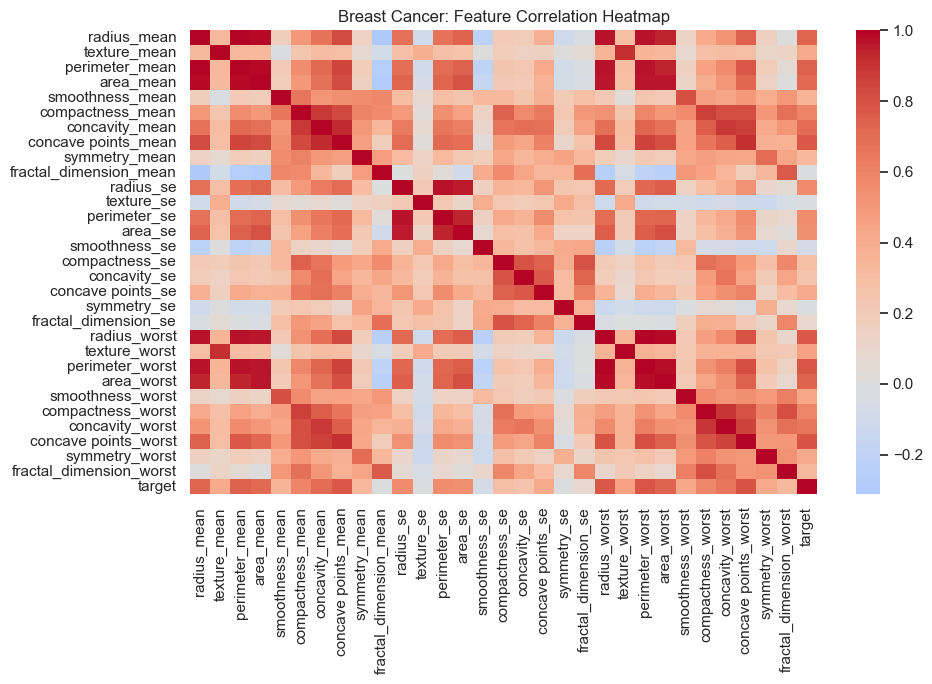

In [7]:
# Correlation heatmaps for compact datasets.
for name, (X, y) in datasets.items():
    corr_df = X.copy()
    corr_df["target"] = y.values
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_df.corr(numeric_only=True), cmap="coolwarm", center=0)
    plt.title(f"{name}: Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()


## 6. Train/test split

A stratified split preserves the class distribution in the training and test sets.


In [8]:
splits = {}

for name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
    splits[name] = X_train, X_test, y_train, y_test
    print(name, "train:", X_train.shape, "test:", X_test.shape)


Heart Disease train: (237, 13) test: (60, 13)
Diabetes train: (614, 8) test: (154, 8)
Breast Cancer train: (455, 30) test: (114, 30)


## 7. Define classification models

For Logistic Regression and SVM, missing values are imputed and numerical features are standardized.

Random Forest and XGBoost use tree-based splits, so scaling is not required.


In [9]:
def make_models():
    scaled_preprocess = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    tree_preprocess = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    return {
        "Logistic Regression": Pipeline([
            ("prep", scaled_preprocess),
            ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
        ]),
        "SVM": Pipeline([
            ("prep", scaled_preprocess),
            ("model", SVC(probability=True, random_state=RANDOM_STATE))
        ]),
        "Random Forest": Pipeline([
            ("prep", tree_preprocess),
            ("model", RandomForestClassifier(
                n_estimators=400,
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]),
        "XGBoost": Pipeline([
            ("prep", tree_preprocess),
            ("model", XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="logloss",
                random_state=RANDOM_STATE
            ))
        ])
    }


## 8. Train and evaluate all models


In [10]:
results = []
trained_models = {}

for dataset_name, (X_train, X_test, y_train, y_test) in splits.items():
    trained_models[dataset_name] = {}

    for model_name, model in make_models().items():
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        row = {
            "Dataset": dataset_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        }
        results.append(row)
        trained_models[dataset_name][model_name] = model

results_df = pd.DataFrame(results)
results_df.sort_values(["Dataset", "ROC-AUC"], ascending=[True, False])


,Dataset,Model,Accuracy,Precision,Recall,F1,ROC-AUC
10,Breast Cancer,Random Forest,0.973684,1.000000,0.928571,0.962963,0.997354
8,Breast Cancer,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
9,Breast Cancer,SVM,0.973684,1.000000,0.928571,0.962963,0.994709
11,Breast Cancer,XGBoost,0.964912,1.000000,0.904762,0.950000,0.994048
7,Diabetes,XGBoost,0.753247,0.642857,0.666667,0.654545,0.826296
6,Diabetes,Random Forest,0.772727,0.693878,0.629630,0.660194,0.825370
4,Diabetes,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822963
5,Diabetes,SVM,0.753247,0.660000,0.611111,0.634615,0.792407
2,Heart Disease,Random Forest,0.850000,0.913043,0.750000,0.823529,0.953683
0,Heart Disease,Logistic Regression,0.916667,1.000000,0.821429,0.901961,0.953125


In [11]:
# Display results rounded for readability.
results_display = results_df.copy()
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
results_display[metric_cols] = results_display[metric_cols].round(4)
display(results_display.sort_values(["Dataset", "ROC-AUC"], ascending=[True, False]))


,Dataset,Model,Accuracy,Precision,Recall,F1,ROC-AUC
10,Breast Cancer,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9974
8,Breast Cancer,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
9,Breast Cancer,SVM,0.9737,1.0000,0.9286,0.9630,0.9947
11,Breast Cancer,XGBoost,0.9649,1.0000,0.9048,0.9500,0.9940
7,Diabetes,XGBoost,0.7532,0.6429,0.6667,0.6545,0.8263
6,Diabetes,Random Forest,0.7727,0.6939,0.6296,0.6602,0.8254
4,Diabetes,Logistic Regression,0.7143,0.6087,0.5185,0.5600,0.8230
5,Diabetes,SVM,0.7532,0.6600,0.6111,0.6346,0.7924
2,Heart Disease,Random Forest,0.8500,0.9130,0.7500,0.8235,0.9537
0,Heart Disease,Logistic Regression,0.9167,1.0000,0.8214,0.9020,0.9531


## 9. Classification reports and confusion matrices


Heart Disease

--- Logistic Regression ---
              precision    recall  f1-score   support

     Class 0       0.86      1.00      0.93        32
     Class 1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60



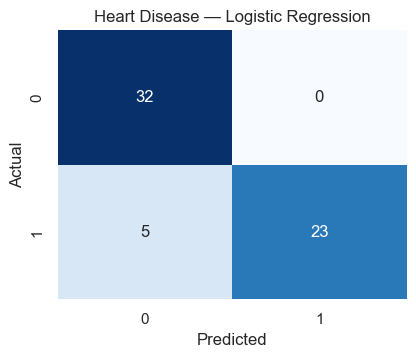


--- SVM ---
              precision    recall  f1-score   support

     Class 0       0.84      1.00      0.91        32
     Class 1       1.00      0.79      0.88        28

    accuracy                           0.90        60
   macro avg       0.92      0.89      0.90        60
weighted avg       0.92      0.90      0.90        60



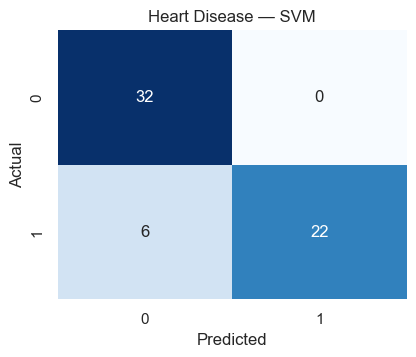


--- Random Forest ---
              precision    recall  f1-score   support

     Class 0       0.81      0.94      0.87        32
     Class 1       0.91      0.75      0.82        28

    accuracy                           0.85        60
   macro avg       0.86      0.84      0.85        60
weighted avg       0.86      0.85      0.85        60



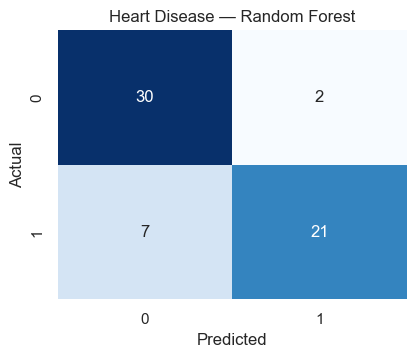


--- XGBoost ---
              precision    recall  f1-score   support

     Class 0       0.79      0.94      0.86        32
     Class 1       0.91      0.71      0.80        28

    accuracy                           0.83        60
   macro avg       0.85      0.83      0.83        60
weighted avg       0.85      0.83      0.83        60



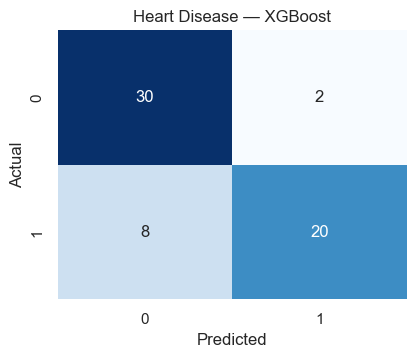

Diabetes

--- Logistic Regression ---
              precision    recall  f1-score   support

     Class 0       0.76      0.82      0.79       100
     Class 1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



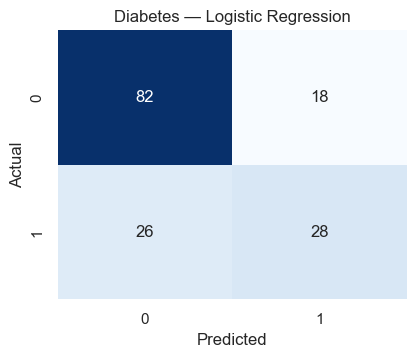


--- SVM ---
              precision    recall  f1-score   support

     Class 0       0.80      0.83      0.81       100
     Class 1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



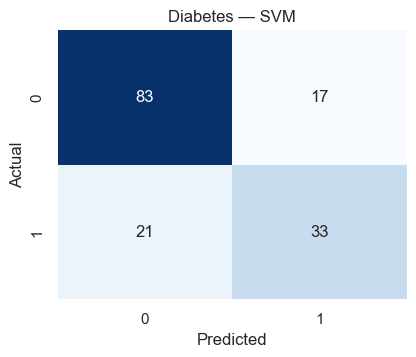


--- Random Forest ---
              precision    recall  f1-score   support

     Class 0       0.81      0.85      0.83       100
     Class 1       0.69      0.63      0.66        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



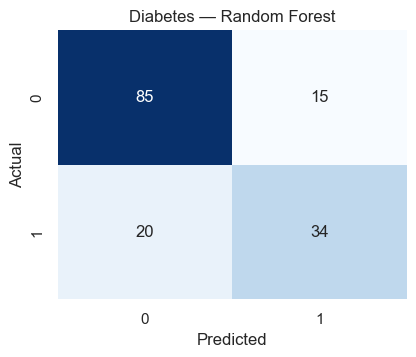


--- XGBoost ---
              precision    recall  f1-score   support

     Class 0       0.82      0.80      0.81       100
     Class 1       0.64      0.67      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.76      0.75      0.75       154



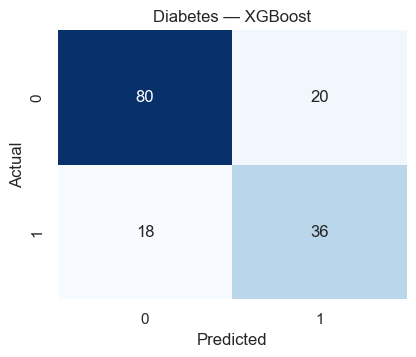

Breast Cancer

--- Logistic Regression ---
              precision    recall  f1-score   support

     Class 0       0.96      0.99      0.97        72
     Class 1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



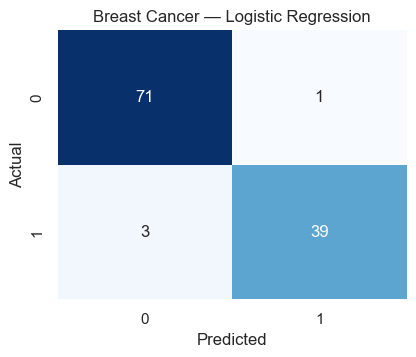


--- SVM ---
              precision    recall  f1-score   support

     Class 0       0.96      1.00      0.98        72
     Class 1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



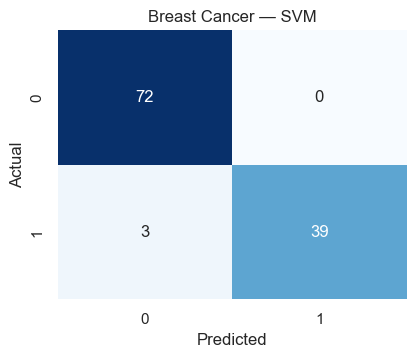


--- Random Forest ---
              precision    recall  f1-score   support

     Class 0       0.96      1.00      0.98        72
     Class 1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



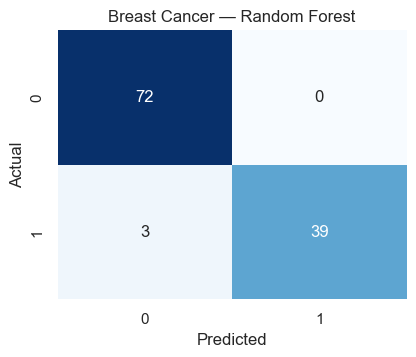


--- XGBoost ---
              precision    recall  f1-score   support

     Class 0       0.95      1.00      0.97        72
     Class 1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



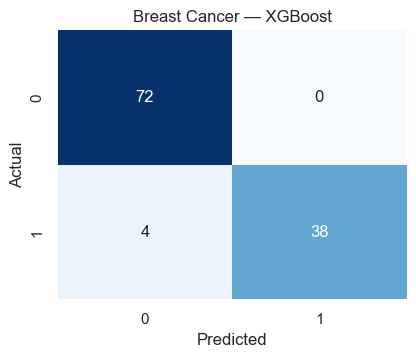

In [12]:
for dataset_name, (X_train, X_test, y_train, y_test) in splits.items():
    print("=" * 80)
    print(dataset_name)

    for model_name, model in trained_models[dataset_name].items():
        y_pred = model.predict(X_test)

        print(f"\n--- {model_name} ---")
        print(classification_report(
            y_test, y_pred,
            target_names=["Class 0", "Class 1"],
            zero_division=0
        ))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4.5, 3.5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f"{dataset_name} — {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()


## 10. ROC curves

ROC-AUC summarizes discrimination across classification thresholds. The curves below are generated only from the held-out test sets.


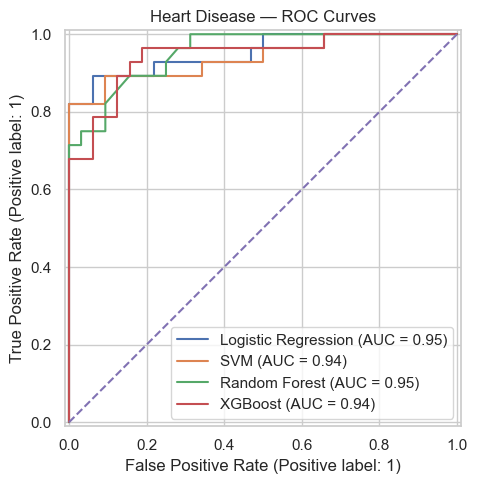

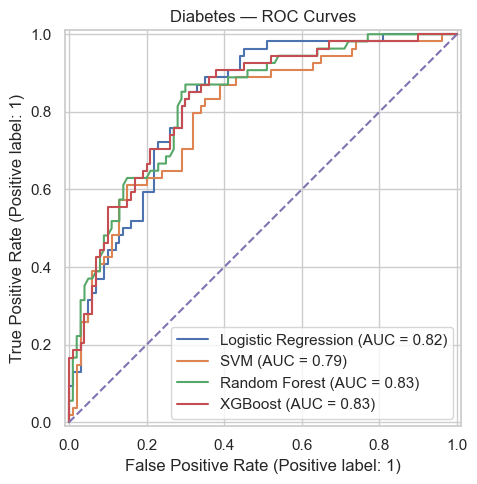

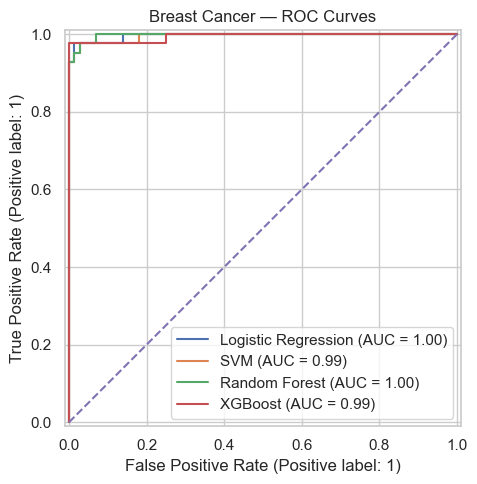

In [13]:
for dataset_name, (X_train, X_test, y_train, y_test) in splits.items():
    plt.figure(figsize=(7, 5))

    for model_name, model in trained_models[dataset_name].items():
        y_prob = model.predict_proba(X_test)[:, 1]
        RocCurveDisplay.from_predictions(
            y_test, y_prob,
            name=model_name,
            ax=plt.gca()
        )

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.title(f"{dataset_name} — ROC Curves")
    plt.tight_layout()
    plt.show()


## 11. Model comparison


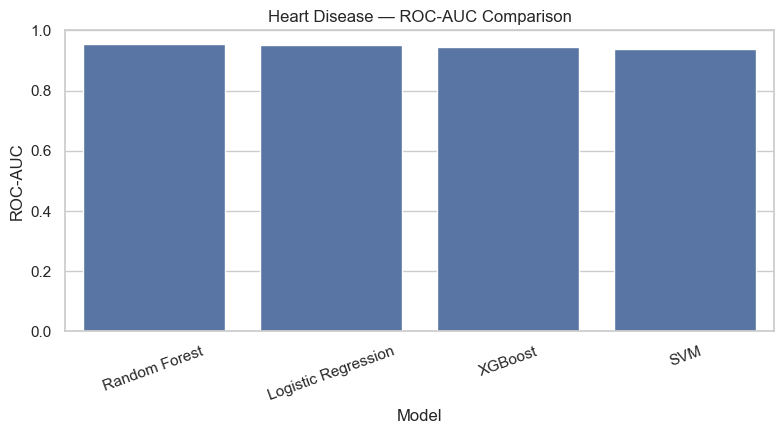

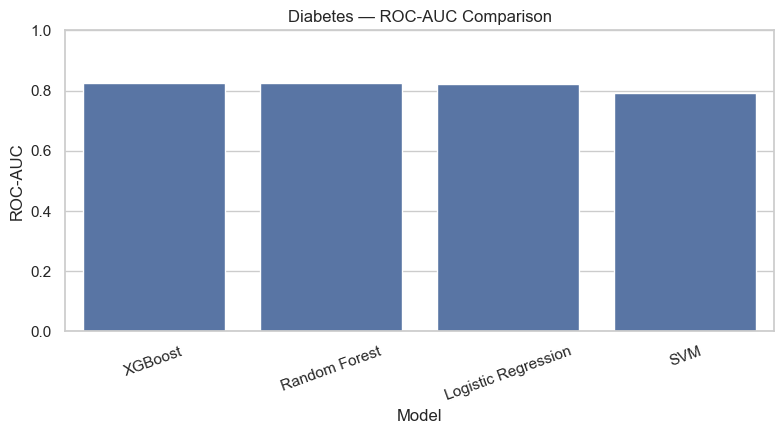

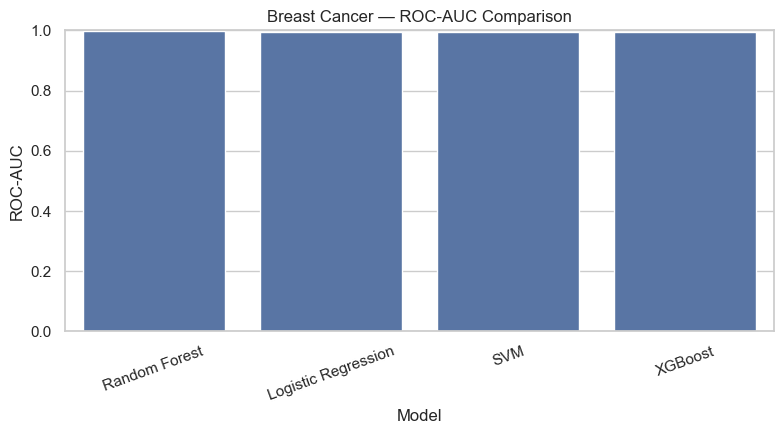

Dataset,Breast Cancer,Diabetes,Heart Disease
Model,,,
Logistic Regression,0.9960,0.8230,0.9531
Random Forest,0.9974,0.8254,0.9537
SVM,0.9947,0.7924,0.9397
XGBoost,0.9940,0.8263,0.9442


In [14]:
for dataset_name in results_df["Dataset"].unique():
    subset = results_df[results_df["Dataset"] == dataset_name].sort_values("ROC-AUC", ascending=False)

    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=subset, x="Model", y="ROC-AUC")
    plt.ylim(0, 1)
    plt.title(f"{dataset_name} — ROC-AUC Comparison")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

display(
    results_df.pivot(index="Model", columns="Dataset", values="ROC-AUC")
    .round(4)
)


## 12. Selecting a model for demonstration

For an educational demo, we select the model with the highest **test ROC-AUC within each dataset**. This is not a clinical recommendation and does not establish that one algorithm is medically superior.


In [15]:
selected_models = {}

for dataset_name in results_df["Dataset"].unique():
    row = results_df[results_df["Dataset"] == dataset_name].sort_values(
        "ROC-AUC", ascending=False
    ).iloc[0]

    selected_models[dataset_name] = {
        "model_name": row["Model"],
        "model": trained_models[dataset_name][row["Model"]]
    }

    print(dataset_name, "->", row["Model"], "ROC-AUC =", round(row["ROC-AUC"], 4))


Heart Disease -> Random Forest ROC-AUC = 0.9537
Diabetes -> XGBoost ROC-AUC = 0.8263
Breast Cancer -> Random Forest ROC-AUC = 0.9974


## 13. Example patient prediction

The helper below takes a dictionary of feature values and returns the model's class and estimated probability.

**Use only values matching the dataset's feature names and units.**


In [16]:
def predict_patient(dataset_name, patient_data):
    X, _ = datasets[dataset_name]
    model_info = selected_models[dataset_name]
    model = model_info["model"]

    row = pd.DataFrame([patient_data])
    row = row.reindex(columns=X.columns)

    prediction = int(model.predict(row)[0])
    probability = float(model.predict_proba(row)[0, 1])

    return {
        "dataset": dataset_name,
        "model": model_info["model_name"],
        "predicted_class": prediction,
        "estimated_probability_of_class_1": probability
    }

# Example: create a patient using median values from the dataset.
# Replace these values with actual feature values before using the function.
for dataset_name, (X, y) in datasets.items():
    example = X.median(numeric_only=True).to_dict()
    print(predict_patient(dataset_name, example))


{'dataset': 'Heart Disease', 'model': 'Random Forest', 'predicted_class': 0, 'estimated_probability_of_class_1': 0.1475}
{'dataset': 'Diabetes', 'model': 'XGBoost', 'predicted_class': 1, 'estimated_probability_of_class_1': 0.5229796171188354}
{'dataset': 'Breast Cancer', 'model': 'Random Forest', 'predicted_class': 0, 'estimated_probability_of_class_1': 0.0}


## 14. Save results

The metrics are exported so they can be included in a report or presentation.


In [17]:
results_df.to_csv("disease_prediction_model_results.csv", index=False)

print("Saved: disease_prediction_model_results.csv")
display(results_df.round(4))


Saved: disease_prediction_model_results.csv


,Dataset,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Heart Disease,Logistic Regression,0.9167,1.0000,0.8214,0.9020,0.9531
1,Heart Disease,SVM,0.9000,1.0000,0.7857,0.8800,0.9397
2,Heart Disease,Random Forest,0.8500,0.9130,0.7500,0.8235,0.9537
3,Heart Disease,XGBoost,0.8333,0.9091,0.7143,0.8000,0.9442
4,Diabetes,Logistic Regression,0.7143,0.6087,0.5185,0.5600,0.8230
5,Diabetes,SVM,0.7532,0.6600,0.6111,0.6346,0.7924
6,Diabetes,Random Forest,0.7727,0.6939,0.6296,0.6602,0.8254
7,Diabetes,XGBoost,0.7532,0.6429,0.6667,0.6545,0.8263
8,Breast Cancer,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
9,Breast Cancer,SVM,0.9737,1.0000,0.9286,0.9630,0.9947


# Final project conclusion

This project implements a complete supervised-learning pipeline for disease prediction using Kaggle medical datasets. It includes data inspection, preprocessing, exploratory analysis, train/test splitting, four classification algorithms, multiple evaluation metrics, confusion matrices, ROC curves, model comparison, and an example prediction function.

**Key learning points**
- Logistic Regression provides an interpretable linear classification baseline.
- SVM can model nonlinear decision boundaries through kernels.
- Random Forest combines many decision trees.
- XGBoost builds boosted trees sequentially.
- Accuracy alone is not sufficient for medical classification; precision, recall, F1 and ROC-AUC should also be examined.
- Test-set performance is dataset-specific and should not be interpreted as clinical performance.

**Medical disclaimer:** These models are educational demonstrations on public datasets. They are not validated medical devices and should not be used for diagnosis or treatment decisions.
